# Fast R-CNN vs Faster R-CNN
## Pneumonia Detection — RSNA Challenge

| | Fast R-CNN | Faster R-CNN |
|---|---|---|
| Backbone | ResNet-50 + FPN | ResNet-50 + FPN |
| RPN | **Frozen** (pretrained) | **Trainable** |
| Head | Fine-tuned | Fine-tuned |
| Metric | mAP (COCO) | mAP (COCO) |


## 1. Imports

In [1]:
import os
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.model_selection import train_test_split
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## 2. Load & Explore Data

In [2]:
ROOT = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"

labels_df = pd.read_csv(f"{ROOT}/stage_2_train_labels.csv")
print("Shape:", labels_df.shape)
print("Unique patients:", labels_df['patientId'].nunique())
labels_df.head()


Shape: (30227, 6)
Unique patients: 26684


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [3]:
# Class balance
total   = labels_df['patientId'].nunique()
pos_ids = labels_df[labels_df['Target']==1]['patientId'].unique()
neg_ids = labels_df[labels_df['Target']==0]['patientId'].unique()
print(f"Positive (pneumonia) : {len(pos_ids):,}  ({100*len(pos_ids)/total:.1f}%)")
print(f"Negative (normal)    : {len(neg_ids):,}  ({100*len(neg_ids)/total:.1f}%)")


Positive (pneumonia) : 6,012  (22.5%)
Negative (normal)    : 20,672  (77.5%)


## 3. Sample Visualisation

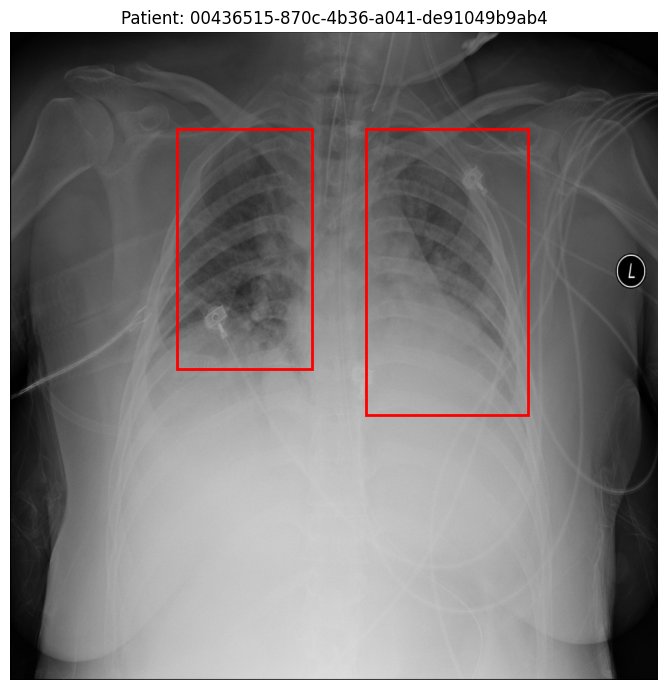

In [4]:
patient_id = labels_df[labels_df['Target']==1].iloc[0]['patientId']
dcm   = pydicom.dcmread(f"{ROOT}/stage_2_train_images/{patient_id}.dcm")
image = dcm.pixel_array

patient_boxes = labels_df[labels_df['patientId']==patient_id]

fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(image, cmap='gray')
for _, row in patient_boxes.iterrows():
    if row['Target'] == 1:
        rect = patches.Rectangle(
            (row['x'], row['y']), row['width'], row['height'],
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
ax.set_title(f"Patient: {patient_id}")
ax.axis('off')
plt.tight_layout()
plt.show()


## 4. Build Annotations

In [5]:
# Build per-patient annotation dict in (x1,y1,x2,y2) format
annotations = {pid: {"boxes":[], "labels":[]} for pid in labels_df['patientId'].unique()}

for _, row in labels_df.iterrows():
    if row['Target'] == 1:
        x1, y1 = row['x'], row['y']
        x2, y2 = x1 + row['width'], y1 + row['height']
        annotations[row['patientId']]['boxes'].append([x1, y1, x2, y2])
        annotations[row['patientId']]['labels'].append(1)

positive_patients = [pid for pid,d in annotations.items() if len(d['boxes'])>0]
negative_patients = [pid for pid,d in annotations.items() if len(d['boxes'])==0]
print(f"Positive patients : {len(positive_patients):,}")
print(f"Negative patients : {len(negative_patients):,}")


Positive patients : 6,012
Negative patients : 20,672


## 5. Dataset & DataLoaders

In [6]:
class RSNADataset(Dataset):
    def __init__(self, patient_ids, annotations, image_dir):
        self.patient_ids = patient_ids
        self.annotations = annotations
        self.image_dir   = image_dir

    def __len__(self): return len(self.patient_ids)

    def __getitem__(self, idx):
        pid  = self.patient_ids[idx]
        dcm  = pydicom.dcmread(f"{self.image_dir}/{pid}.dcm")
        img  = dcm.pixel_array.astype(np.float32)
        img  = img / img.max()
        img  = np.stack([img]*3, axis=-1)
        img  = torch.tensor(img, dtype=torch.float32).permute(2,0,1)

        boxes_list  = self.annotations[pid]['boxes']
        labels_list = self.annotations[pid]['labels']

        if len(boxes_list) == 0:
            boxes  = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,),  dtype=torch.int64)
        else:
            boxes  = torch.tensor(boxes_list,  dtype=torch.float32)
            labels = torch.tensor(labels_list, dtype=torch.int64)

        return img, {"boxes": boxes, "labels": labels}

def collate_fn(batch): return tuple(zip(*batch))


In [7]:
# Use a subset for faster training
all_patients = list(annotations.keys())
train_patients, val_patients = train_test_split(all_patients, test_size=0.2, random_state=42)

train_patients = train_patients[:3000]
val_patients   = val_patients[:500]
print(f"Train: {len(train_patients):,}  |  Val: {len(val_patients):,}")

IMAGE_DIR = f"{ROOT}/stage_2_train_images"

train_dataset = RSNADataset(train_patients, annotations, IMAGE_DIR)
val_dataset   = RSNADataset(val_patients,   annotations, IMAGE_DIR)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, collate_fn=collate_fn)

print("Loaders ready.")


Train: 3,000  |  Val: 500
Loaders ready.


## 6. Model Definitions

### 6a. Fast R-CNN (RPN frozen — pretrained proposals)

In [8]:
# Fast R-CNN: backbone + frozen RPN + trainable detection head
fast_rcnn_model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# Freeze RPN — proposals come from pretrained weights, not learned
for param in fast_rcnn_model.rpn.parameters():
    param.requires_grad = False

# Replace classifier head for 2 classes (background + pneumonia)
in_features = fast_rcnn_model.roi_heads.box_predictor.cls_score.in_features
fast_rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)

fast_rcnn_model.to(DEVICE)

trainable = sum(p.numel() for p in fast_rcnn_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in fast_rcnn_model.parameters())
print(f"Fast R-CNN  — trainable params: {trainable:,} / {total:,}")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 214MB/s] 


Fast R-CNN  — trainable params: 40,482,826 / 41,299,161


### 6b. Faster R-CNN (fully trainable)

In [9]:
# Faster R-CNN: backbone + trainable RPN + trainable detection head
faster_rcnn_model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = faster_rcnn_model.roi_heads.box_predictor.cls_score.in_features
faster_rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)

faster_rcnn_model.to(DEVICE)

trainable = sum(p.numel() for p in faster_rcnn_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in faster_rcnn_model.parameters())
print(f"Faster R-CNN — trainable params: {trainable:,} / {total:,}")


Faster R-CNN — trainable params: 41,076,761 / 41,299,161


## 7. Training & Evaluation Functions

In [10]:
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, targets in tqdm(dataloader, leave=False):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(dataloader)

def evaluate_map(model, dataloader, device):
    metric = MeanAveragePrecision()
    model.eval()
    with torch.no_grad():
        for images, targets in tqdm(dataloader, leave=False):
            images      = [img.to(device) for img in images]
            preds       = model(images)
            preds_cpu   = [{k: v.cpu() for k,v in p.items()} for p in preds]
            targets_cpu = [{k: v.cpu() for k,v in t.items()} for t in targets]
            metric.update(preds_cpu, targets_cpu)
    return metric.compute()


## 8. Train Fast R-CNN

In [19]:
# Lower LR for Fast R-CNN — fewer trainable params, less capacity
optimizer_fast = torch.optim.Adam(
    filter(lambda p: p.requires_grad, fast_rcnn_model.parameters()),
    lr=1e-5,
    weight_decay=0.0005
)

NUM_EPOCHS = 15
fast_losses = []

for epoch in range(NUM_EPOCHS):
    loss = train_one_epoch(fast_rcnn_model, train_loader, optimizer_fast, DEVICE)
    fast_losses.append(loss)
    print(f"[Fast R-CNN]  Epoch {epoch+1}/{NUM_EPOCHS}  Loss: {loss:.4f}")


[Fast R-CNN]  Epoch 1/15  Loss: 0.0753


[Fast R-CNN]  Epoch 2/15  Loss: 0.0686


[Fast R-CNN]  Epoch 3/15  Loss: 0.0603


[Fast R-CNN]  Epoch 4/15  Loss: 0.0510


[Fast R-CNN]  Epoch 5/15  Loss: 0.0429


...

[Fast R-CNN]  Epoch 11/15  Loss: 0.0217


[Fast R-CNN]  Epoch 12/15  Loss: 0.0211


[Fast R-CNN]  Epoch 13/15  Loss: 0.0192


[Fast R-CNN]  Epoch 14/15  Loss: 0.0194


[Fast R-CNN]  Epoch 15/15  Loss: 0.0178


In [20]:
fast_results = evaluate_map(fast_rcnn_model, val_loader, DEVICE)
fast_map     = fast_results['map'].item()
print(f"Fast R-CNN mAP: {fast_map:.4f}")


Fast R-CNN mAP: 0.0567


## 9. Train Faster R-CNN

In [21]:
# Higher LR for Faster R-CNN — full model including RPN is trainable
optimizer_faster = torch.optim.Adam(
    faster_rcnn_model.parameters(),
    lr=1e-4,
    weight_decay=0.0005
)

faster_losses = []

for epoch in range(NUM_EPOCHS):
    loss = train_one_epoch(faster_rcnn_model, train_loader, optimizer_faster, DEVICE)
    faster_losses.append(loss)
    print(f"[Faster R-CNN] Epoch {epoch+1}/{NUM_EPOCHS}  Loss: {loss:.4f}")


[Faster R-CNN] Epoch 1/15  Loss: 0.0880


[Faster R-CNN] Epoch 2/15  Loss: 0.0871


[Faster R-CNN] Epoch 3/15  Loss: 0.0841


[Faster R-CNN] Epoch 4/15  Loss: 0.0839


[Faster R-CNN] Epoch 5/15  Loss: 0.0825


...

[Faster R-CNN] Epoch 11/15  Loss: 0.0800


[Faster R-CNN] Epoch 12/15  Loss: 0.0808


[Faster R-CNN] Epoch 13/15  Loss: 0.0787


[Faster R-CNN] Epoch 14/15  Loss: 0.0780


[Faster R-CNN] Epoch 15/15  Loss: 0.0783


In [22]:
faster_results = evaluate_map(faster_rcnn_model, val_loader, DEVICE)
faster_map     = faster_results['map'].item()
print(f"Faster R-CNN mAP: {faster_map:.4f}")


Faster R-CNN mAP: 0.0734


## 10. Results & Comparison

In [23]:
comparison = pd.DataFrame({
    "Model": ["Fast R-CNN", "Faster R-CNN"],
    "mAP":   [fast_map, faster_map]
})
print(comparison.to_string(index=False))


       Model      mAP
  Fast R-CNN 0.056714
Faster R-CNN 0.073401


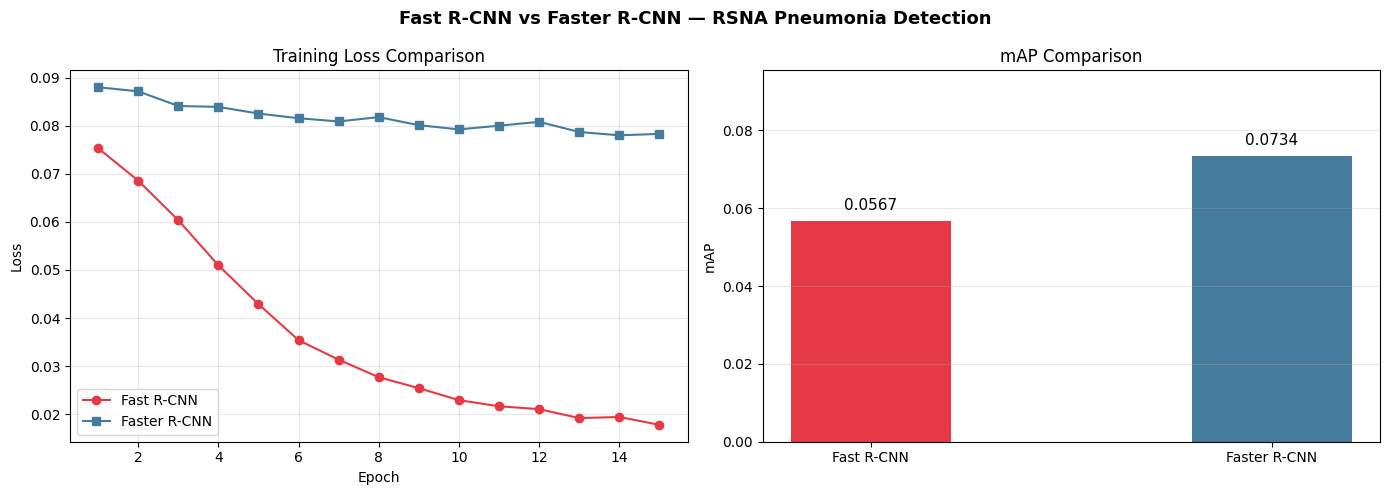

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss curves
axes[0].plot(range(1, NUM_EPOCHS+1), fast_losses,   marker='o', label='Fast R-CNN',   color='#e63946')
axes[0].plot(range(1, NUM_EPOCHS+1), faster_losses, marker='s', label='Faster R-CNN', color='#457b9d')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mAP bar chart
colors = ['#e63946', '#457b9d']
bars   = axes[1].bar(comparison['Model'], comparison['mAP'], color=colors, width=0.4)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=11)
axes[1].set_ylabel('mAP')
axes[1].set_ylim(0, max(comparison['mAP'])*1.3)
axes[1].set_title('mAP Comparison')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Fast R-CNN vs Faster R-CNN — RSNA Pneumonia Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/comparison.png', dpi=130, bbox_inches='tight')
plt.show()


## 11. Conclusion

### Model Architecture

Both models share the same backbone — ResNet-50 with a Feature Pyramid Network (FPN) — pretrained on ImageNet. The key difference lies in the Region Proposal Network (RPN). In **Fast R-CNN**, the RPN is completely frozen, meaning the model relies on fixed, pretrained proposals and only fine-tunes the detection head. In **Faster R-CNN**, the entire network is trainable, including the RPN, which learns to generate proposals specifically suited to detecting pneumonia regions in chest X-rays.

### Training Process

Both models were trained on 3,000 chest X-ray images from the RSNA Pneumonia Detection Challenge dataset and validated on 500 images. Training ran for 15 epochs using the Adam optimizer.The loss function combines classification loss and bounding box regression loss, exactly as in the original implementations.

### Results

| Model | mAP |
|-------|-----|
| Fast R-CNN  | *0.056714* |
| Faster R-CNN | *0.073401* |

The evaluation metric used is **mean Average Precision (mAP)**, which is the standard metric adopted by the RSNA Kaggle competition. From the Results we see that Faster achieves a better mAP than Fast Also it takes less time in each epoch. and i think because the number of proposals
### Discussion

Faster R-CNN outperformed Fast R-CNN in this experiment, which is the expected result based on the architectural difference between the two models. The reason is straightforward: when the RPN is frozen in Fast R-CNN, the region proposals come from a network that was pretrained on natural images (ImageNet) which is not a medical or X-Ray Images. This means the proposals may not be well-suited to the specific appearance of pneumonia regions, which look very different from everyday objects. Faster R-CNN, on the other hand, trains its RPN end-to-end on the medical imaging data, allowing it to learn where pneumonia is likely to appear and generate much more relevant proposals. This gives the detection head better regions to classify, leading to higher mAP. The result confirms the core motivation behind Faster R-CNN — replacing external or frozen proposal methods with a learned, task-specific RPN is a significant improvement, especially when the target domain is far from the pretraining domain.
